In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
df = pd.read_csv("netflix_titles.csv")
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [99]:
#Print No of Rows and Columns
print(df.shape)
#Prints Name of Columns
print(df.columns)

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [100]:
#Prints Column,Non-Null Count and Datatype
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [101]:
#Prints Sum of Null Values in each column
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [102]:
#Prints basic statistics of numerical columns. In this case release_year
print(df.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


type
Movie      6131
TV Show    2676
Name: count, dtype: int64




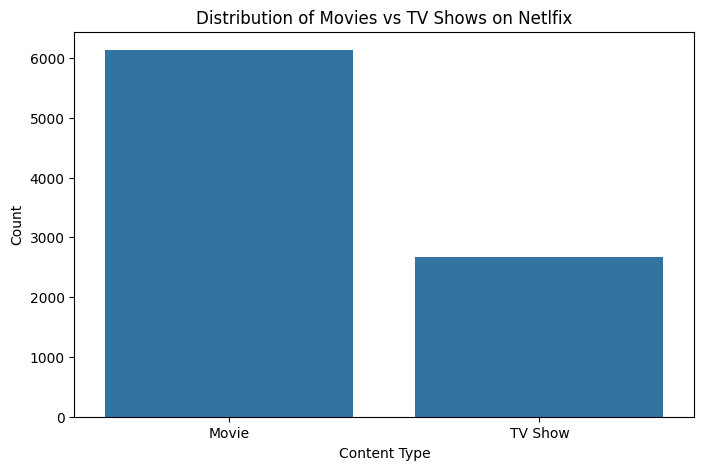

In [103]:
#Prints Number of Movies and Shows
print(df['type'].value_counts())
print("\n")

#Creates a Basic Bar Chart
plt.figure(figsize=(8,5)) #Sets Size of Chart
sns.countplot(data=df,x='type')
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.title("Distribution of Movies vs TV Shows on Netlfix")
plt.show()

In [104]:
print(df.isnull().sum())

#Replacin all the missing values one by one
df['director']=df['director'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')

#What ffill does it takes the date of the previous entry and puts that
df['date_added']=df['date_added'].ffill()
df['rating']=df['rating'].fillna('Not Rated')
#Dropping those movies/shows which don't have a duration
df.dropna(subset=['duration'],inplace=True)

print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [105]:
#I had to use .astype(str) to convert to string as I had already converted it to a datetime . Strip is done to remove leading/trailing spaces as it'll give an error
df['date_added'] = df['date_added'].astype(str).str.strip()

#Convert date_added to a datetime object
df['date_added'] = pd.to_datetime(df['date_added'])
#Extract Year and store it as a seperate column
df['year_added'] = df['date_added'].dt.year

df[['date_added','year_added']].head()

,date_added,year_added
0,2021-09-25,2021
1,2021-09-24,2021
2,2021-09-24,2021
3,2021-09-24,2021
4,2021-09-24,2021


In [106]:
#Prints No of Duplicate Values for each Column
print(df.duplicated().sum())

0


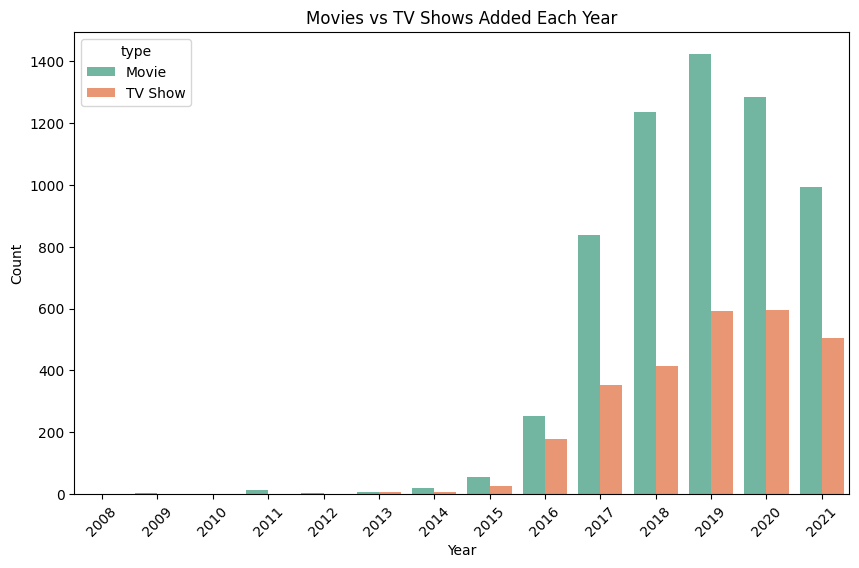

In [107]:
plt.figure(figsize=(10,6))

#Palette chooses a color theme for the bars
#Hue shall split the bars according to type column . Can use it to split bars according to another categorical variable
sns.countplot(data=df,x='year_added',hue='type',palette='Set2')
#Rotates x-axis labels by 45 degrees
plt.xticks(rotation=45)
plt.title('Movies vs TV Shows Added Each Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()



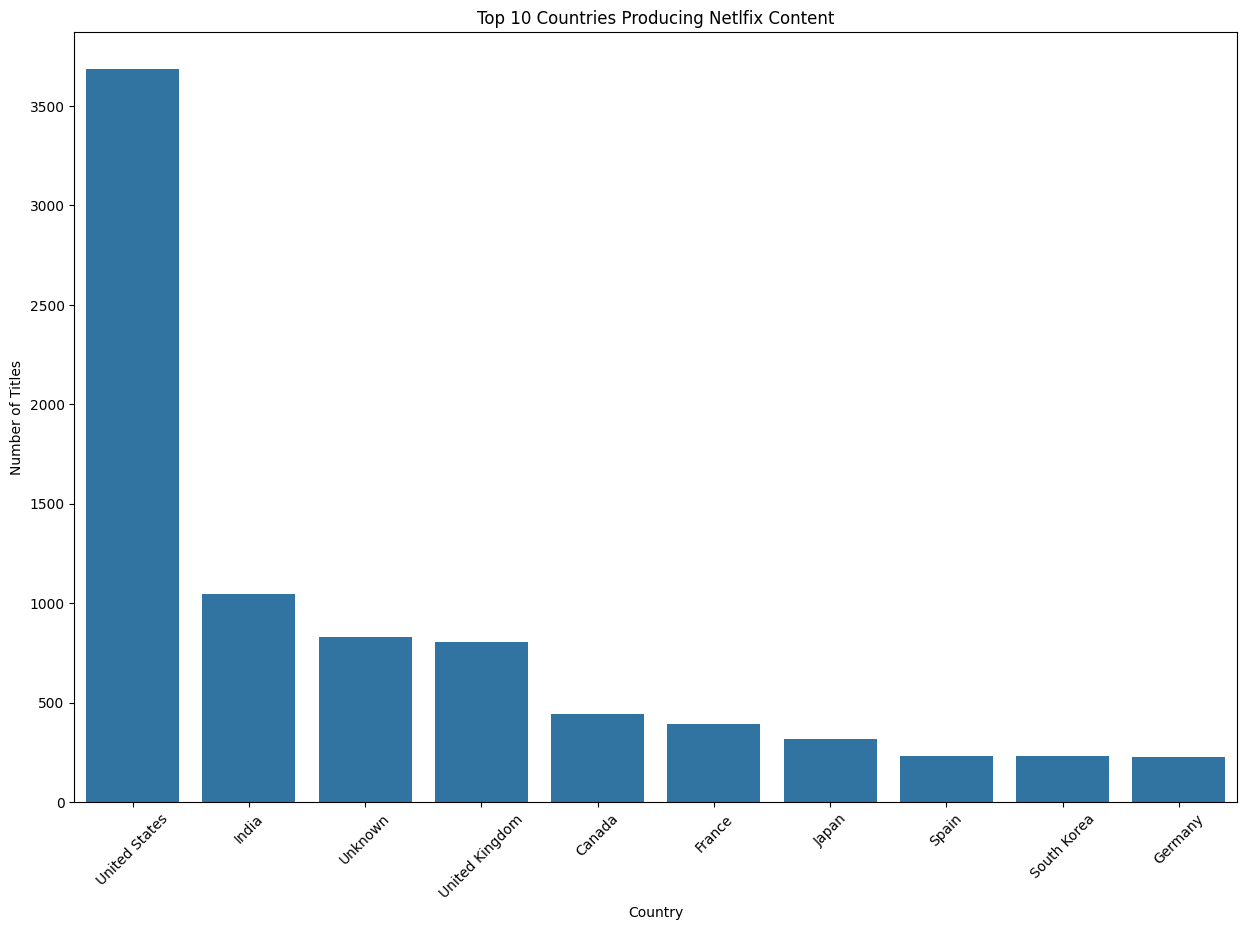

In [108]:
df_countries = df['country'].str.split(',',expand=True).stack().str.strip().value_counts()

top10_countries = df_countries.head(10)

plt.figure(figsize=(15, 10))

sns.barplot(x=top10_countries.index,y=top10_countries.values)
plt.xticks(rotation=45)
plt.title('Top 10 Countries Producing Netlfix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()



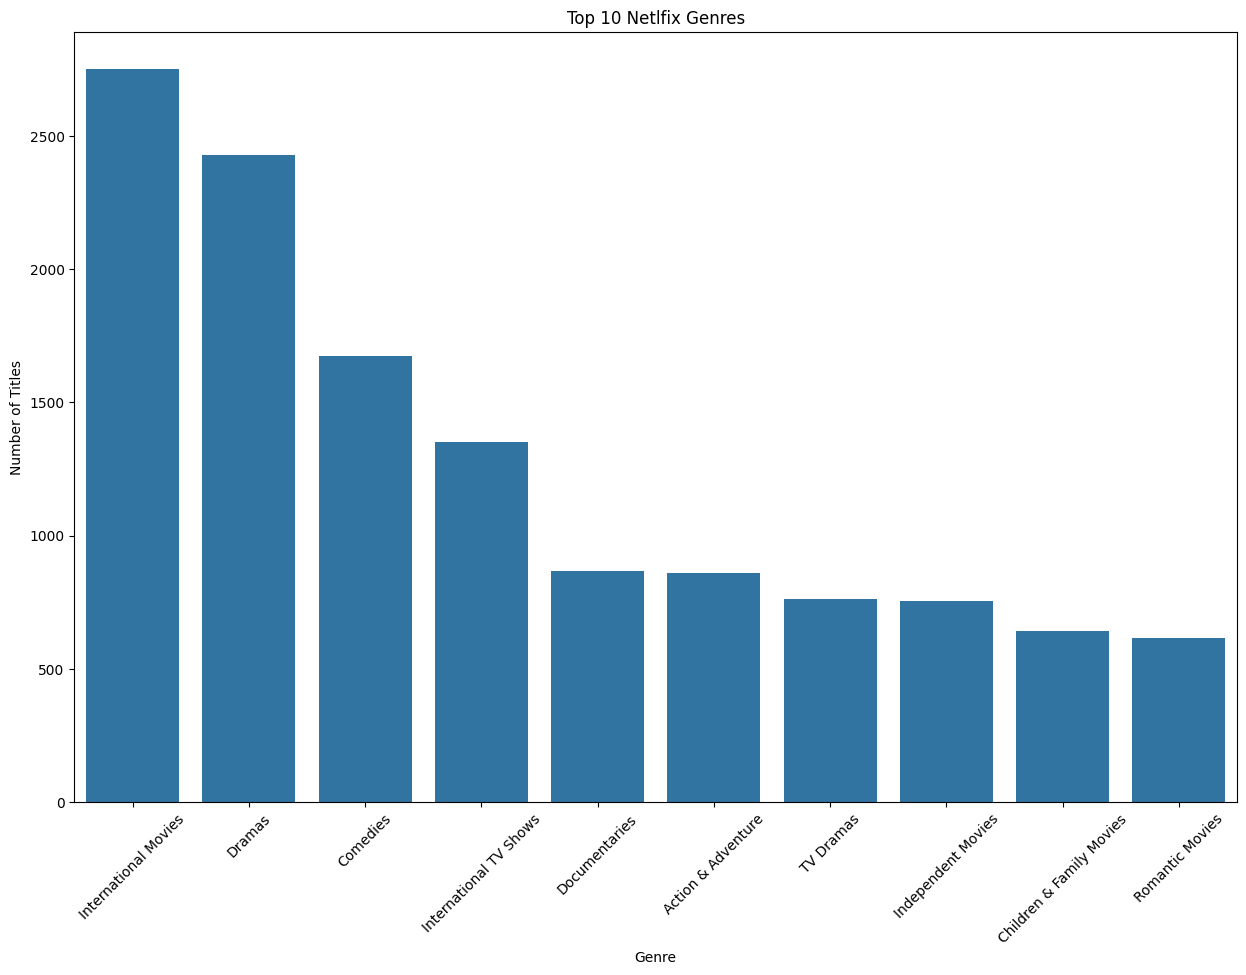

In [109]:
df_genres = df['listed_in'].str.split(',',expand=True).stack().str.strip().value_counts()

top10_genres = df_genres.head(10)

plt.figure(figsize=(15, 10))
sns.barplot(x=top10_genres.index,y=top10_genres.values)
plt.xticks(rotation=45)
plt.title('Top 10 Netlfix Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.show()



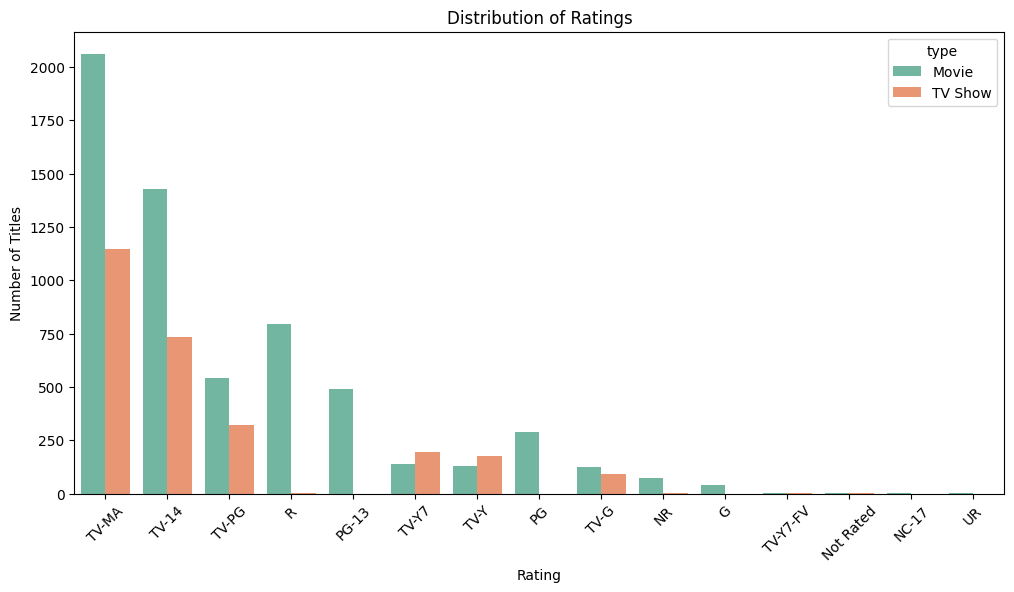

In [110]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,x='rating',order=df['rating'].value_counts().index,hue='type',palette='Set2')
plt.xticks(rotation=45)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.show()

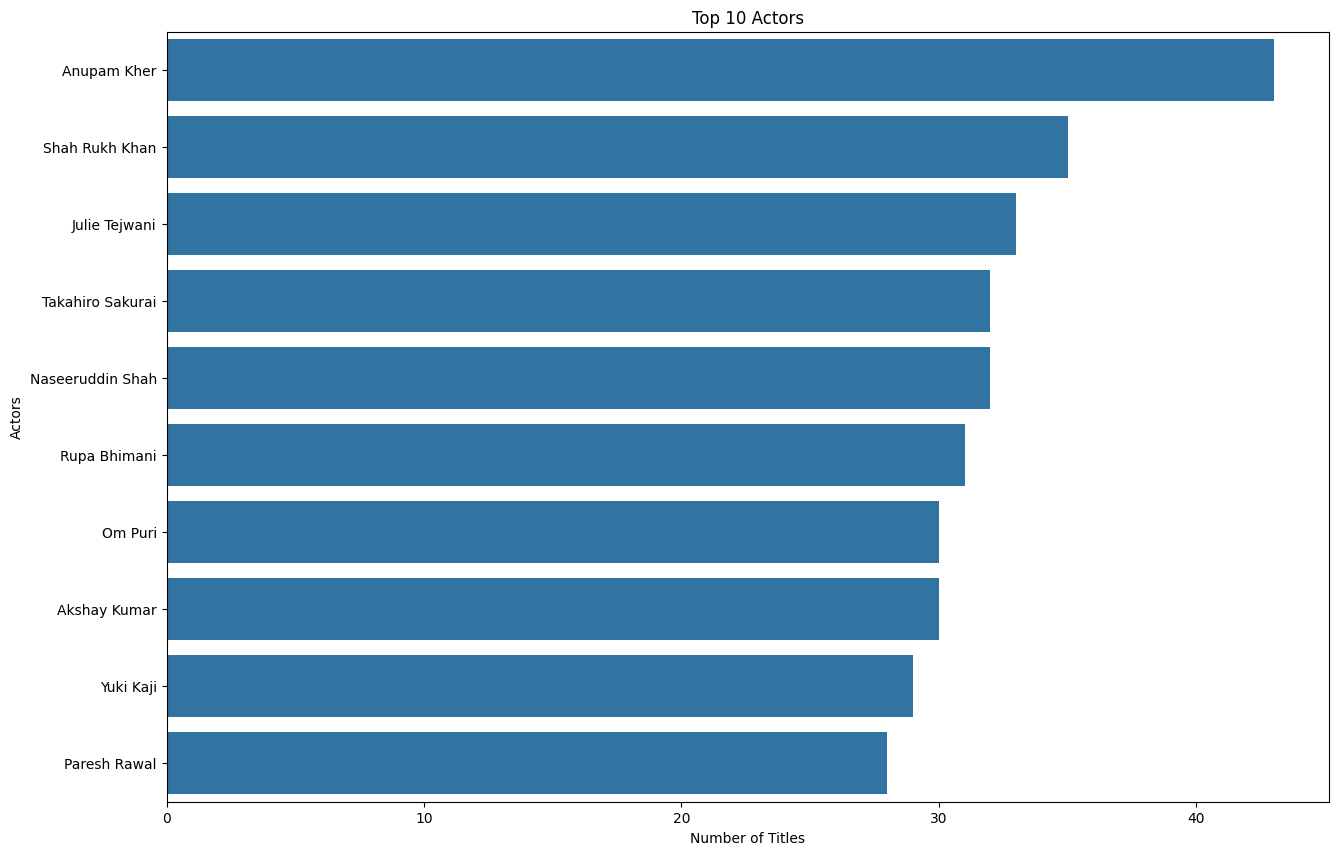

In [111]:
df_actors = df['cast'].str.split(',',expand=True).stack().str.strip().value_counts()

df_actors = df_actors[df_actors.index != 'Unknown']
top10_actors = df_actors.head(10)

plt.figure(figsize=(15, 10))

sns.barplot(y=top10_actors.index,x=top10_actors.values)
plt.title('Top 10 Actors')
plt.xlabel('Number of Titles')
plt.ylabel('Actors')
plt.show()



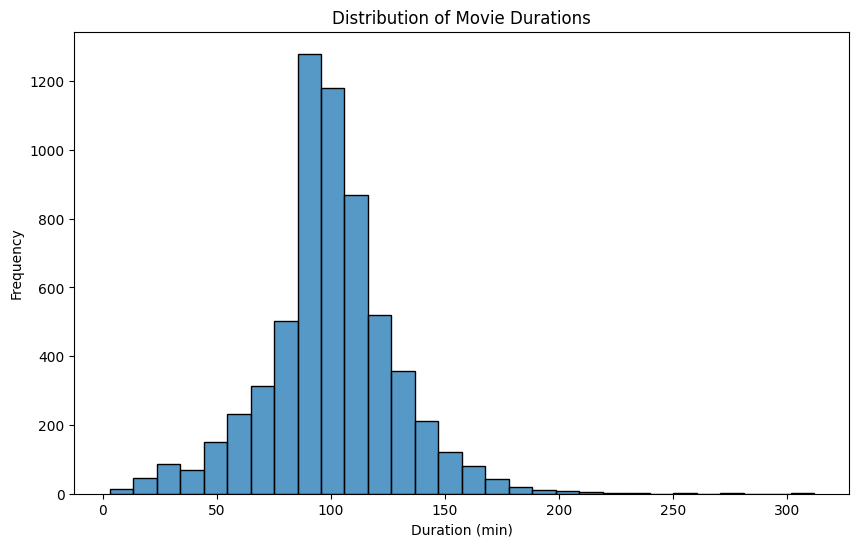

In [112]:
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration'] = df_movies['duration'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(10,6))

sns.histplot(df_movies['duration'],bins=30)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (min)")
plt.ylabel("Frequency")
plt.show()



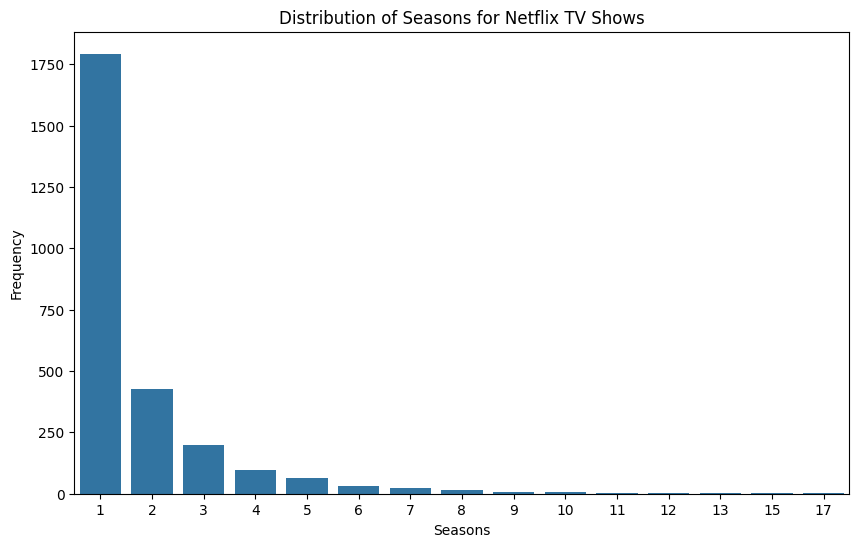

In [113]:
df_shows = df[df['type']== 'TV Show'].copy()
df_shows['duration'] = df_shows['duration'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(10,6))

sns.countplot(data=df_shows,x='duration')
plt.title("Distribution of Seasons for Netflix TV Shows")
plt.xlabel("Seasons")
plt.ylabel("Frequency")
plt.show()